In [1]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]

df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_more.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]

In [16]:
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v1.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_short = df_env_top.iloc[:,np.append(range(0,28), range(56,61))]
df_env_top_pred = df_env_short.iloc[:,np.append(range(0,22), range(25,33))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_top_pred = df_env_top_pred.drop(['TKN_pct'], axis=1)

In [22]:
X, y = np.array(np.log(df_env_top_pred+1)), np.log(df_env_short['Respiratio'].iloc[:,1].values)

def mixup_data(x1, x2, y1, y2):

    lam   = 0.5 #Sample from beta distribution
    x_lam = lam * x1 + (1.0 - lam) * x2 #Mixup inputs vectors
    y_lam = lam * y1 + (1.0 - lam) * y2 #Mixup output vectors

    return x_lam, y_lam

X_mix = [[None] * 29]
y_mix = []
for i in np.arange(len(y)):
    for j in np.arange(i+1,len(y)):
        x_new, y_new = mixup_data(X[i,:], X[j,:], y[i], y[j])
        X_mix = np.append(X_mix, [x_new], axis=0)
        y_mix = np.append(y_mix, y_new)
    print(i)
    print(X_mix.shape)
    print(y_mix.shape)

0
(63, 29)
(62,)
1
(124, 29)
(123,)
2
(184, 29)
(183,)
3
(243, 29)
(242,)
4
(301, 29)
(300,)
5
(358, 29)
(357,)
6
(414, 29)
(413,)
7
(469, 29)
(468,)
8
(523, 29)
(522,)
9
(576, 29)
(575,)
10
(628, 29)
(627,)
11
(679, 29)
(678,)
12
(729, 29)
(728,)
13
(778, 29)
(777,)
14
(826, 29)
(825,)
15
(873, 29)
(872,)
16
(919, 29)
(918,)
17
(964, 29)
(963,)
18
(1008, 29)
(1007,)
19
(1051, 29)
(1050,)
20
(1093, 29)
(1092,)
21
(1134, 29)
(1133,)
22
(1174, 29)
(1173,)
23
(1213, 29)
(1212,)
24
(1251, 29)
(1250,)
25
(1288, 29)
(1287,)
26
(1324, 29)
(1323,)
27
(1359, 29)
(1358,)
28
(1393, 29)
(1392,)
29
(1426, 29)
(1425,)
30
(1458, 29)
(1457,)
31
(1489, 29)
(1488,)
32
(1519, 29)
(1518,)
33
(1548, 29)
(1547,)
34
(1576, 29)
(1575,)
35
(1603, 29)
(1602,)
36
(1629, 29)
(1628,)
37
(1654, 29)
(1653,)
38
(1678, 29)
(1677,)
39
(1701, 29)
(1700,)
40
(1723, 29)
(1722,)
41
(1744, 29)
(1743,)
42
(1764, 29)
(1763,)
43
(1783, 29)
(1782,)
44
(1801, 29)
(1800,)
45
(1818, 29)
(1817,)
46
(1834, 29)
(1833,)
47
(1849, 29)


In [44]:
df_env_top_pred['Long']

Sample
ANZA_TOP   -116.254011
BLAN_TOP    -78.072070
CFS1_TOP    -78.038180
CFS2_TOP    -81.434174
CLBJ_TOP    -97.570431
               ...    
WY01_TOP   -109.712562
WY03_TOP   -109.143313
WY09_TOP   -109.946757
WY10_TOP   -109.971750
WY15_TOP   -108.751004
Name: Long, Length: 63, dtype: float64

In [2]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [3]:
df_env_top['Respiratio'].iloc[:,1]

Sample
ANZA_TOP     11.40
BLAN_TOP     52.40
CFS1_TOP     81.07
CFS2_TOP     24.84
CLBJ_TOP     24.60
             ...  
WY01_TOP    406.90
WY03_TOP    667.00
WY09_TOP    324.30
WY10_TOP    196.10
WY15_TOP    412.50
Name: Respiratio, Length: 63, dtype: float64

In [30]:
df_env_top_pred = df_env_top.iloc[:,np.append(range(0,22), range(25,28))]
df_env_top_pred = df_env_top_pred.fillna(df_env_top_pred.mean())

gridsearch CV

data augmentation
mixup, add noise to training only https://arxiv.org/pdf/1710.09412.pdf



findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


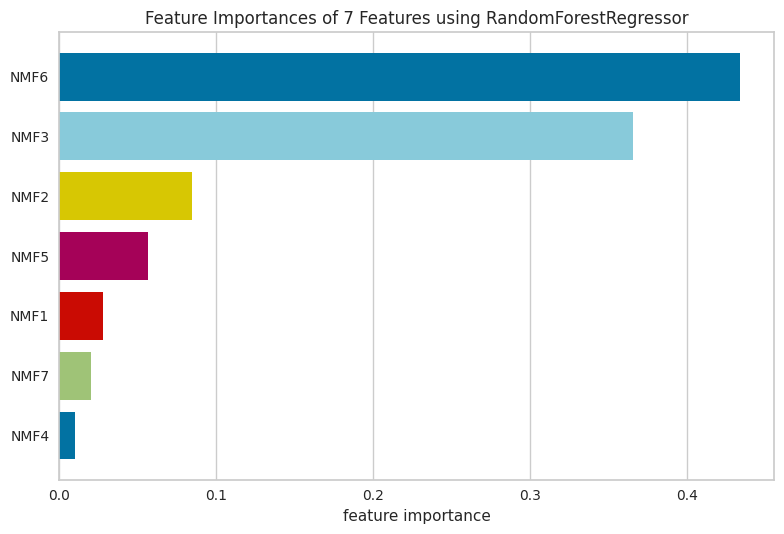

<AxesSubplot:title={'center':'Feature Importances of 7 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [12]:
from sklearn.ensemble import RandomForestRegressor
from yellowbrick.model_selection import FeatureImportances

X, y = datah7.T, df_env_top['Respiratio'].iloc[:,1].values
viz = FeatureImportances(RandomForestRegressor(), labels=['NMF1','NMF2','NMF3','NMF4','NMF5','NMF6','NMF7'], relative=False)

# Fit and show the feature importancesQ
viz.fit(X, y)
viz.show()

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X, y = datah7.T, np.log(df_env_top['Respiratio'].iloc[:,1].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
clf.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'ccp_alpha': array([1.00000000e-05, 1.20450354e-05, 1.45082878e-05, 1.74752840e-05,
       2.10490414e-05, 2.53536449e-05, 3.05385551e-05, 3.67837977e-05,
       4.43062146e-05, 5.33669923e-05, 6.42807312e-05, 7.74263683e-05,
       9.32603347e-05, 1.12332403e-04, 1.35304777e-04, 1.62975083e-04,
       1.96304065e-04, 2.36448941e-04, 2....
       2.91505306e+01, 3.51119173e+01, 4.22924287e+01, 5.09413801e+01,
       6.13590727e+01, 7.39072203e+01, 8.90215085e+01, 1.07226722e+02,
       1.29154967e+02, 1.55567614e+02, 1.87381742e+02, 2.25701972e+02,
       2.71858824e+02, 3.27454916e+02, 3.94420606e+02, 4.75081016e+02,
       5.72236766e+02, 6.89261210e+02, 8.30217568e+02, 1.00000000e+03]),
                         'max_depth': array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42,
       44, 46, 48])},
             return_train_score=True)

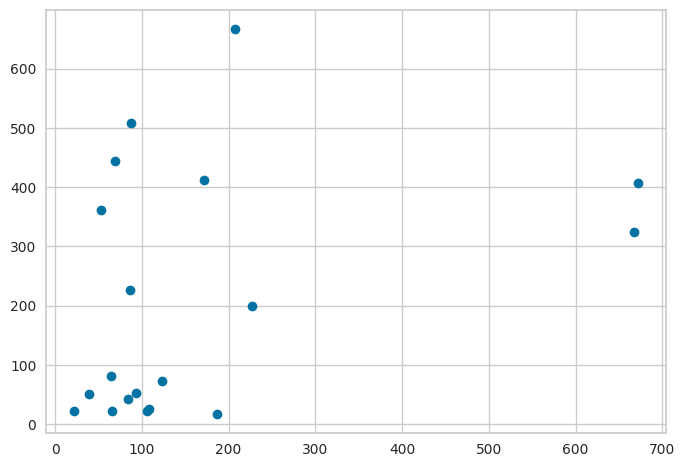

In [15]:
import matplotlib.pyplot as plt

plt.plot(clf.predict(X_test), y_test, marker='o', linewidth=0)


In [7]:
clf.best_estimator_.score(X_train,y_train)

0.882544358783559

In [6]:
clf.best_score_

0.058897206205023256

In [8]:
clf.cv_results_['mean_test_score'].max()

0.058897206205023256

In [31]:
X, y = df_env_top_pred, np.log(df_env_top['Respiratio'].iloc[:,1].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
clf.fit(X_train, y_train)
print(clf.best_score_)
print(clf.best_estimator_.score(X_train,y_train))

0.2378376576134456
0.8763677585956771


In [32]:
clf.best_estimator_

RandomForestRegressor(ccp_alpha=0.024770763559917114, max_depth=18)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


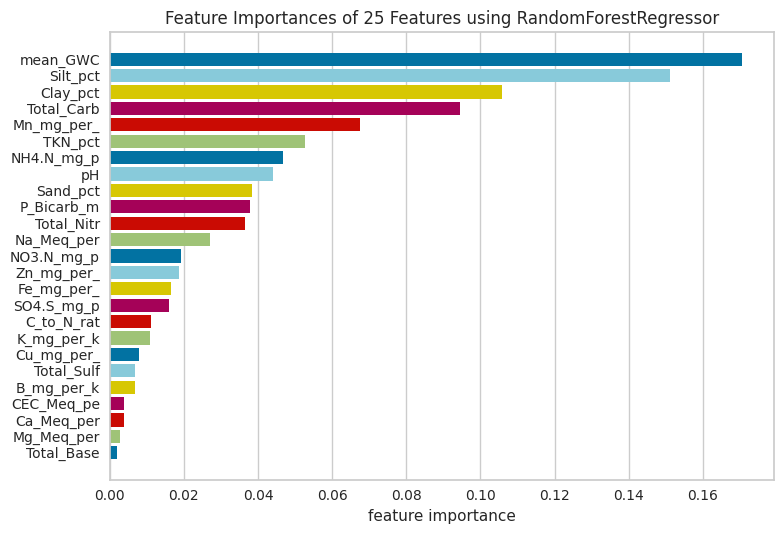

<AxesSubplot:title={'center':'Feature Importances of 25 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [33]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(RandomForestRegressor(ccp_alpha=0.024770763559917114, max_depth=18), labels=df_env_top_pred.columns, relative=False)

# Fit and show the feature importancesQ
viz.fit(X, y)
viz.show()

In [35]:
def mixup_data(x1, x2, y1, y2):

    lam   = 0.5 #Sample from beta distribution
    x_lam = lam * x1 + (1.0 - lam) * x2 #Mixup inputs vectors
    y_lam = lam * y1 + (1.0 - lam) * y2 #Mixup output vectors

    return x_lam, y_lam

X_mix = [[None] * 7]
y_mix = []
for i in np.arange(len(y_train)):
    for j in np.arange(i+1,len(y_train)):
        x_new, y_new = mixup_data(X_train[i,:], X_train[j,:], y_train[i], y_train[j])
        X_mix = np.append(X_mix, [x_new], axis=0)
        y_mix = np.append(y_mix, y_new)
    print(i)
    print(X_mix.shape)
    print(y_mix.shape)


0
(44, 7)
(43,)
1
(86, 7)
(85,)
2
(127, 7)
(126,)
3
(167, 7)
(166,)
4
(206, 7)
(205,)
5
(244, 7)
(243,)
6
(281, 7)
(280,)
7
(317, 7)
(316,)
8
(352, 7)
(351,)
9
(386, 7)
(385,)
10
(419, 7)
(418,)
11
(451, 7)
(450,)
12
(482, 7)
(481,)
13
(512, 7)
(511,)
14
(541, 7)
(540,)
15
(569, 7)
(568,)
16
(596, 7)
(595,)
17
(622, 7)
(621,)
18
(647, 7)
(646,)
19
(671, 7)
(670,)
20
(694, 7)
(693,)
21
(716, 7)
(715,)
22
(737, 7)
(736,)
23
(757, 7)
(756,)
24
(776, 7)
(775,)
25
(794, 7)
(793,)
26
(811, 7)
(810,)
27
(827, 7)
(826,)
28
(842, 7)
(841,)
29
(856, 7)
(855,)
30
(869, 7)
(868,)
31
(881, 7)
(880,)
32
(892, 7)
(891,)
33
(902, 7)
(901,)
34
(911, 7)
(910,)
35
(919, 7)
(918,)
36
(926, 7)
(925,)
37
(932, 7)
(931,)
38
(937, 7)
(936,)
39
(941, 7)
(940,)
40
(944, 7)
(943,)
41
(946, 7)
(945,)
42
(947, 7)
(946,)
43
(947, 7)
(946,)


In [38]:
parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
clf.fit(X_mix[1:,:], y_mix)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'ccp_alpha': array([1.00000000e-05, 1.20450354e-05, 1.45082878e-05, 1.74752840e-05,
       2.10490414e-05, 2.53536449e-05, 3.05385551e-05, 3.67837977e-05,
       4.43062146e-05, 5.33669923e-05, 6.42807312e-05, 7.74263683e-05,
       9.32603347e-05, 1.12332403e-04, 1.35304777e-04, 1.62975083e-04,
       1.96304065e-04, 2.36448941e-04, 2....
       2.91505306e+01, 3.51119173e+01, 4.22924287e+01, 5.09413801e+01,
       6.13590727e+01, 7.39072203e+01, 8.90215085e+01, 1.07226722e+02,
       1.29154967e+02, 1.55567614e+02, 1.87381742e+02, 2.25701972e+02,
       2.71858824e+02, 3.27454916e+02, 3.94420606e+02, 4.75081016e+02,
       5.72236766e+02, 6.89261210e+02, 8.30217568e+02, 1.00000000e+03]),
                         'max_depth': array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42,
       44, 46, 48])},
             return_train_score=True)

In [39]:
clf.cv_results_['mean_test_score'].max()

0.670147804241085

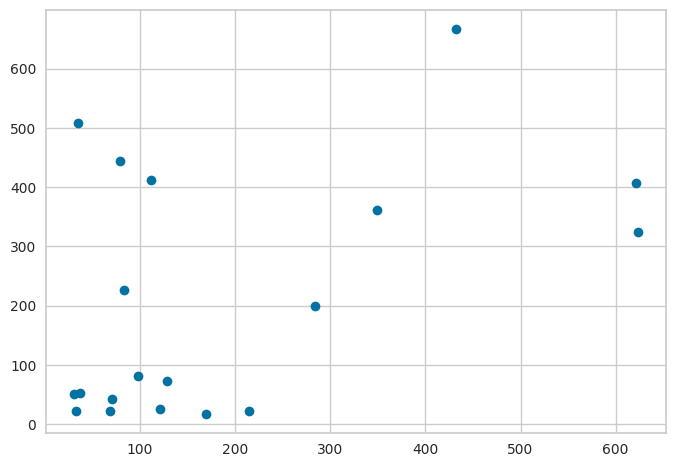

In [40]:
plt.plot(clf.predict(X_test), y_test, marker='o', linewidth=0)

In [42]:
clf.best_estimator_.score(X_test, y_test)

0.022743320221092378

In [1]:
import joblib
clf = joblib.load('/home/shic892/corems/RF_NMF_log_nolignin_4149_top_respiration_log.pkl')

In [14]:
import pandas as pd
import numpy as np
df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_more.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]

results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_no_lignin_4149x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

from sklearn.model_selection import train_test_split
X, y = np.log(datah7.T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [8]:
clf.score(X_test, y_test)

0.01829644525412366

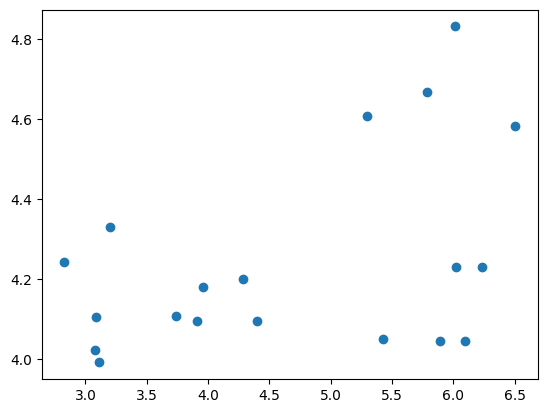

In [7]:
import matplotlib.pyplot as plt
plt.plot(y_test, clf.predict(X_test),marker='o', linewidth=0)

In [9]:
clf = joblib.load('/home/shic892/corems/RF_NMF_nolignin_log_top_respiration_log_test.pkl')

In [15]:
clf.score(X_test, y_test)

-0.17411759544887406

In [16]:
clf.best_params_

{'ccp_alpha': 1.7782794100389228,
 'max_depth': 30,
 'max_features': 'log2',
 'min_samples_split': 4,
 'n_estimators': 302}

In [12]:
df_env_top_pred = df_env_top.iloc[:,np.append(range(0,22), range(25,28))]
df_env_top_pred = df_env_top_pred.fillna(df_env_top_pred.mean())

X = np.log(df_env_top_pred+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)